<a href="https://colab.research.google.com/github/Sumathi3355/LIBRARY_MANAGEMENT_SYS/blob/main/kalai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

Saving covid_dataset.csv to covid_dataset.csv


In [10]:
# Load the dataset
df = pd.read_csv("covid_dataset.csv")

# Display first 5 rows
df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,11-10-2021,0,0,0,0,0,Negative,Yes,female,Other
1,11-10-2021,0,0,0,0,0,Negative,Yes,male,Other
2,11-10-2021,0,0,0,0,0,Negative,No,female,Other
3,11-10-2021,0,0,0,0,0,Negative,Yes,female,Other
4,11-10-2021,0,0,0,0,0,Negative,Yes,female,Other


In [11]:
# Number of records (rows) and attributes (columns)
rows, columns = df.shape

print("Number of Records:", rows)
print("Number of Attributes:", columns)

Number of Records: 1048575
Number of Attributes: 10


In [12]:
# Check missing values in each column
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
test_date              0
cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
corona_result          0
age_60_and_above       0
gender                 0
test_indication        0
dtype: int64


In [17]:
# Display all column names
print("Dataset Columns:")
print(df.columns)

# Display target variable information
print("\nTarget Variable: corona_result")

print("\nUnique Values:")
print(df["corona_result"].unique())

print("\nDistribution of Target Variable:")
print(df["corona_result"].value_counts())

Dataset Columns:
Index(['test_date', 'cough', 'fever', 'sore_throat', 'shortness_of_breath',
       'head_ache', 'corona_result', 'age_60_and_above', 'gender',
       'test_indication'],
      dtype='object')

Target Variable: corona_result

Unique Values:
['Negative' 'Positive']

Distribution of Target Variable:
corona_result
Negative    955604
Positive     92971
Name: count, dtype: int64


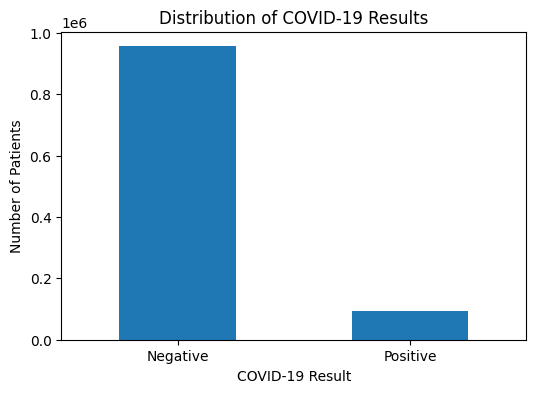

In [18]:
# Plot the distribution of COVID-19 results
plt.figure(figsize=(6, 4))

df["corona_result"].value_counts().plot(kind="bar")

plt.title("Distribution of COVID-19 Results")
plt.xlabel("COVID-19 Result")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

plt.show()

In [19]:
# Select the required columns
selected_columns = [
    "age_60_and_above",
    "fever",
    "cough",
    "sore_throat",
    "corona_result"
]

covid_df = df[selected_columns].copy()

# Display first five rows
covid_df.head()

,age_60_and_above,fever,cough,sore_throat,corona_result
0,Yes,0,0,0,Negative
1,Yes,0,0,0,Negative
2,No,0,0,0,Negative
3,Yes,0,0,0,Negative
4,Yes,0,0,0,Negative


In [21]:
# Check missing values
print("Missing Values Before Handling:")
print(covid_df.isnull().sum())

Missing Values Before Handling:
age_60_and_above    0
fever               0
cough               0
sore_throat         0
corona_result       0
dtype: int64


In [20]:
# Fill missing values using mode
for column in covid_df.columns:
    covid_df[column] = covid_df[column].fillna(covid_df[column].mode()[0])

# Verify that no missing values remain
print("Missing Values After Handling:")
print(covid_df.isnull().sum())

Missing Values After Handling:
age_60_and_above    0
fever               0
cough               0
sore_throat         0
corona_result       0
dtype: int64


In [22]:
# Convert all selected columns into categorical datatype
for column in covid_df.columns:
    covid_df[column] = covid_df[column].astype("category")

# Display data types
print(covid_df.dtypes)

age_60_and_above    category
fever               category
cough               category
sore_throat         category
corona_result       category
dtype: object


In [23]:
# Display first five rows of the preprocessed dataset
print("Preprocessed Dataset:")
covid_df.head()

Preprocessed Dataset:


,age_60_and_above,fever,cough,sore_throat,corona_result
0,Yes,0,0,0,Negative
1,Yes,0,0,0,Negative
2,No,0,0,0,Negative
3,Yes,0,0,0,Negative
4,Yes,0,0,0,Negative


In [24]:
# Display dataset information
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype   
---  ------            --------------    -----   
 0   age_60_and_above  1048575 non-null  category
 1   fever             1048575 non-null  category
 2   cough             1048575 non-null  category
 3   sore_throat       1048575 non-null  category
 4   corona_result     1048575 non-null  category
dtypes: category(5)
memory usage: 5.0 MB


In [26]:
# Dataset shape
print("Dataset Shape:", covid_df.shape)

Dataset Shape: (1048575, 5)


In [27]:
!pip install pgmpy==1.1.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.4/165.4 kB 13.3 MB/s eta 0:00:00


In [29]:
from pgmpy.models import DiscreteBayesianNetwork

In [30]:
# Define the Bayesian Network structure
model = DiscreteBayesianNetwork([
    ("age_60_and_above", "corona_result"),
    ("fever", "corona_result"),
    ("cough", "corona_result"),
    ("sore_throat", "corona_result")
])

print("Bayesian Network created successfully.")

Bayesian Network created successfully.


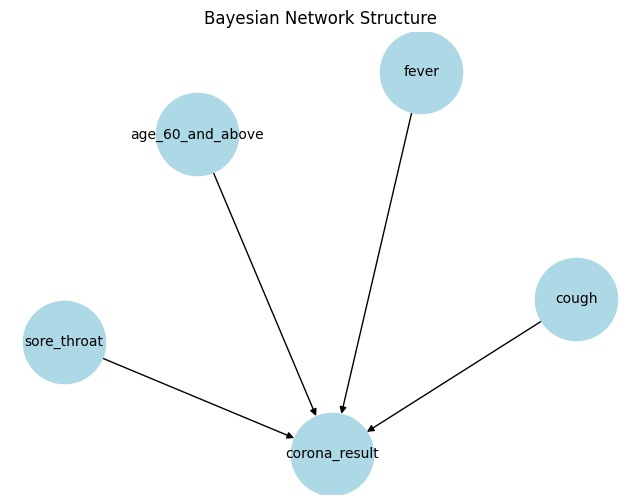

In [34]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
graph = nx.DiGraph()

# Add edges from the Bayesian Network
graph.add_edges_from(model.edges())

# Draw the graph
plt.figure(figsize=(8,6))

nx.draw_networkx(
    graph,
    with_labels=True,
    node_size=3500,
    node_color="lightblue",
    font_size=10,
    arrows=True
)

plt.title("Bayesian Network Structure")
plt.axis("off")
plt.show()

In [35]:
print("Relationships in the Bayesian Network:")

for edge in model.edges():
    print(f"{edge[0]}  --->  {edge[1]}")

Relationships in the Bayesian Network:
age_60_and_above  --->  corona_result
fever  --->  corona_result
cough  --->  corona_result
sore_throat  --->  corona_result


**Relationship Justification**

**age_60_and_above → corona_result:** Age is an important patient characteristic. Older individuals are generally at higher risk of COVID-19 infection and severe illness, so age may influence the test outcome.

**fever → corona_result:** Fever is one of the most common symptoms of COVID-19 and contributes to predicting whether a patient is infected.

**cough → corona_result:** Cough is a frequently observed symptom in COVID-19 patients and helps estimate the probability of infection.

**sore_throat → corona_result:** Sore throat is a possible symptom of COVID-19 and provides additional evidence for the Bayesian Network.

In [44]:
from pgmpy.parameter_estimator import DiscreteMLE

# Learn the probability distributions
model.fit(
    covid_df,
    estimator=DiscreteMLE()
)

print("Probability distributions learned successfully.")

Probability distributions learned successfully.


In [46]:
# Display all learned CPDs
for cpd in model.get_cpds():
    print(cpd)
    print("-" * 80)

+-----------------------+---------+
| age_60_and_above(No)  | 0.86762 |
+-----------------------+---------+
| age_60_and_above(Yes) | 0.13238 |
+-----------------------+---------+
--------------------------------------------------------------------------------
+-------------------------+-----+-----------------------+
| age_60_and_above        | ... | age_60_and_above(Yes) |
+-------------------------+-----+-----------------------+
| cough                   | ... | cough(1)              |
+-------------------------+-----+-----------------------+
| fever                   | ... | fever(1)              |
+-------------------------+-----+-----------------------+
| sore_throat             | ... | sore_throat(1)        |
+-------------------------+-----+-----------------------+
| corona_result(Negative) | ... | 0.14814814814814814   |
+-------------------------+-----+-----------------------+
| corona_result(Positive) | ... | 0.8518518518518519    |
+-------------------------+-----+----------

In [47]:
# Display the CPT of the outcome variable
print("Conditional Probability Table (CPT) of corona_result:\n")

print(model.get_cpds("corona_result"))

Conditional Probability Table (CPT) of corona_result:

+-------------------------+-----+-----------------------+
| age_60_and_above        | ... | age_60_and_above(Yes) |
+-------------------------+-----+-----------------------+
| cough                   | ... | cough(1)              |
+-------------------------+-----+-----------------------+
| fever                   | ... | fever(1)              |
+-------------------------+-----+-----------------------+
| sore_throat             | ... | sore_throat(1)        |
+-------------------------+-----+-----------------------+
| corona_result(Negative) | ... | 0.14814814814814814   |
+-------------------------+-----+-----------------------+
| corona_result(Positive) | ... | 0.8518518518518519    |
+-------------------------+-----+-----------------------+


In [48]:
from pgmpy.inference import VariableElimination

In [49]:
# Create the inference object
inference = VariableElimination(model)

In [50]:
# Query the Bayesian Network
result = inference.query(
    variables=["corona_result"],
    evidence={
        "age_60_and_above": "Yes",
        "fever": 1,
        "cough": 1,
        "sore_throat": 0
    }
)

print(result)

+-------------------------+----------------------+
| corona_result           |   phi(corona_result) |
+=========================+======================+
| corona_result(Negative) |               0.1984 |
+-------------------------+----------------------+
| corona_result(Positive) |               0.8016 |
+-------------------------+----------------------+


In [51]:
# Display probabilities
print("\nPosterior Probabilities:")

print("P(COVID Negative | Evidence) = ", result.values[0])
print("P(COVID Positive | Evidence) = ", result.values[1])


Posterior Probabilities:
P(COVID Negative | Evidence) =  0.19839679358717435
P(COVID Positive | Evidence) =  0.8016032064128257


In [52]:
# Determine the diagnosis
if result.values[1] > result.values[0]:
    print("\nMost Probable Diagnosis: COVID-19 Positive")
else:
    print("\nMost Probable Diagnosis: COVID-19 Negative")


Most Probable Diagnosis: COVID-19 Positive


In [53]:
# Inference before changing fever
before_result = inference.query(
    variables=["corona_result"],
    evidence={
        "age_60_and_above": "Yes",
        "fever": 1,
        "cough": 1,
        "sore_throat": 0
    }
)

print("Before Changing Fever (Fever = Yes)")
print(before_result)

Before Changing Fever (Fever = Yes)
+-------------------------+----------------------+
| corona_result           |   phi(corona_result) |
+=========================+======================+
| corona_result(Negative) |               0.1984 |
+-------------------------+----------------------+
| corona_result(Positive) |               0.8016 |
+-------------------------+----------------------+


In [54]:
# Inference after changing fever
after_result = inference.query(
    variables=["corona_result"],
    evidence={
        "age_60_and_above": "Yes",
        "fever": 0,
        "cough": 1,
        "sore_throat": 0
    }
)

print("\nAfter Changing Fever (Fever = No)")
print(after_result)


After Changing Fever (Fever = No)
+-------------------------+----------------------+
| corona_result           |   phi(corona_result) |
+=========================+======================+
| corona_result(Negative) |               0.2247 |
+-------------------------+----------------------+
| corona_result(Positive) |               0.7753 |
+-------------------------+----------------------+


In [55]:
# Display comparison
print("\nComparison of COVID-19 Positive Probability")

print("Before Change (Fever = Yes):", before_result.values[1])
print("After Change (Fever = No):", after_result.values[1])


Comparison of COVID-19 Positive Probability
Before Change (Fever = Yes): 0.8016032064128257
After Change (Fever = No): 0.7752918287937743


In [56]:
# Compare and explain the result
if after_result.values[1] < before_result.values[1]:
    print("\nInference:")
    print("Changing Fever from Yes to No decreased the probability of COVID-19 Positive.")
    print("This indicates that fever is an important symptom in predicting COVID-19 infection.")
elif after_result.values[1] > before_result.values[1]:
    print("\nInference:")
    print("Changing Fever from Yes to No increased the probability of COVID-19 Positive.")
else:
    print("\nInference:")
    print("Changing the fever status did not affect the probability of COVID-19 Positive.")


Inference:
Changing Fever from Yes to No decreased the probability of COVID-19 Positive.
This indicates that fever is an important symptom in predicting COVID-19 infection.
